In [108]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('FoodImports.csv', encoding="cp1252")
df = df.drop(columns=['RowNumber'])

df.head()

,Commodity,Country,UOM,Category,SubCategory,YearNum,FoodValue
0,Total live animals,CANADA,Million $,Animals,Foods,1999,876.9
1,Total live animals,MEXICO,Million $,Animals,Foods,1999,292.2
2,Total live animals,REST OF WORLD,Million $,Animals,Foods,1999,0.1
3,Total live animals,WORLD,Million $,Animals,Foods,1999,1169.2
4,Total live animals,WORLD (Quantity),"1,000",Animals,Foods,1999,6058.4


In [6]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('FoodImports.csv', encoding="cp1252")
df = df.drop(columns=['RowNumber'])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19838 entries, 0 to 19837
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Commodity    19838 non-null  object 
 1   Country      19838 non-null  object 
 2   UOM          19838 non-null  object 
 3   Category     19838 non-null  object 
 4   SubCategory  19838 non-null  object 
 5   YearNum      19838 non-null  object 
 6   FoodValue    19838 non-null  float64
dtypes: float64(1), object(6)
memory usage: 1.1+ MB


In [8]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('FoodImports.csv', encoding="cp1252")
df = df.drop(columns=['RowNumber'])

missing_value = df.isnull().sum()
print(missing_value)

Commodity      0
Country        0
UOM            0
Category       0
SubCategory    0
YearNum        0
FoodValue      0
dtype: int64


In [10]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('FoodImports.csv', encoding="cp1252")
df = df.drop(columns=['RowNumber'])

unique_category = df['Category'].unique()
unique_category

array(['Animals', 'Meats', 'Fish', 'Vegetables', 'Dairy', 'Fruits',
       'Nuts', 'Coffee', 'Grains', 'VegetablesOil', 'Sweets', 'Cocoa',
       'Other', 'Beverages', 'Food dollars', 'Food volume', 'Prices'],
      dtype=object)

In [12]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('FoodImports.csv', encoding="cp1252")
df = df.drop(columns=['RowNumber'])

df = df[df['UOM'] == 'Million $']
df.head(10)


,Commodity,Country,UOM,Category,SubCategory,YearNum,FoodValue
0,Total live animals,CANADA,Million $,Animals,Foods,1999,876.9
1,Total live animals,MEXICO,Million $,Animals,Foods,1999,292.2
2,Total live animals,REST OF WORLD,Million $,Animals,Foods,1999,0.1
3,Total live animals,WORLD,Million $,Animals,Foods,1999,1169.2
5,"Bovine animals, live",CANADA,Million $,Animals,Foods,1999,639.0
6,"Bovine animals, live",MEXICO,Million $,Animals,Foods,1999,292.1
7,"Bovine animals, live",WORLD,Million $,Animals,Foods,1999,931.1
9,"Swine, live",CANADA,Million $,Animals,Foods,1999,216.1
10,"Swine, live",WORLD,Million $,Animals,Foods,1999,216.2
12,"Sheep and goats, live",CANADA,Million $,Animals,Foods,1999,5.3


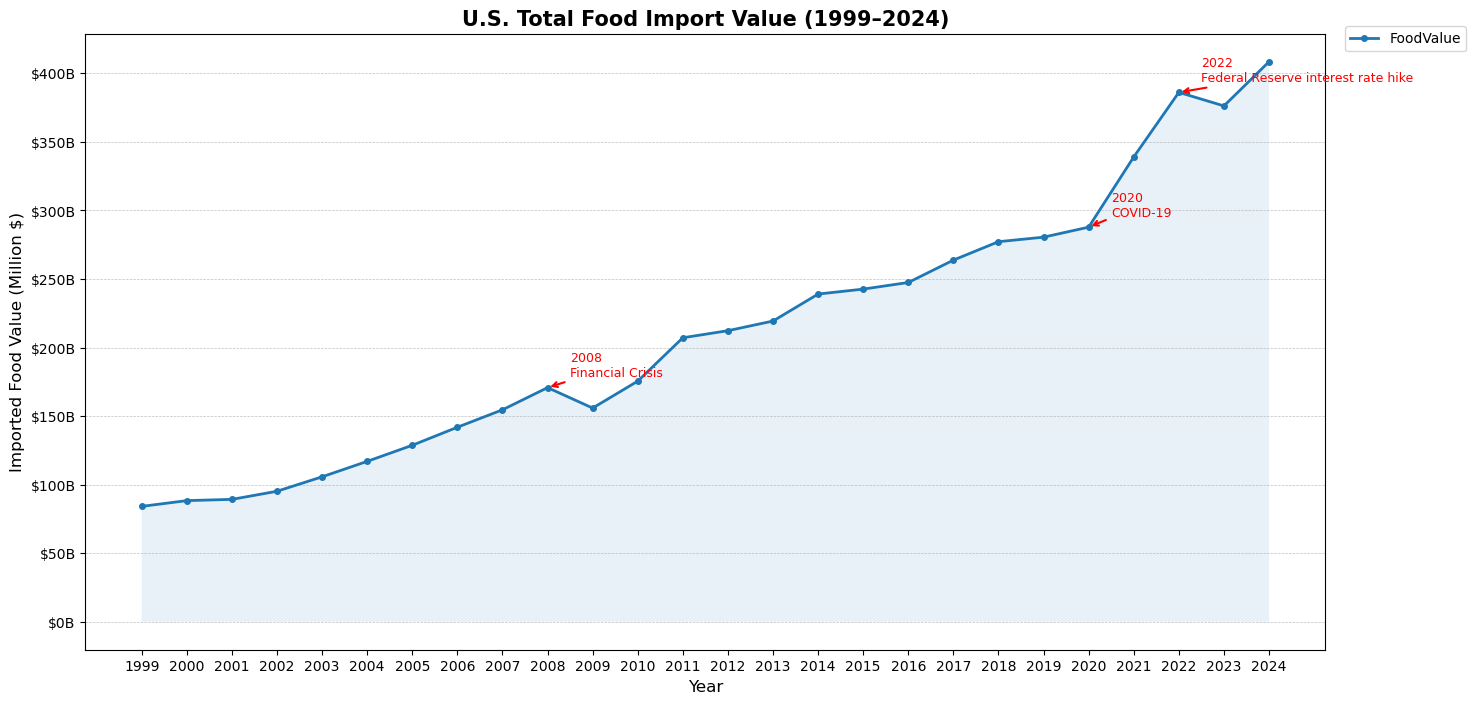

In [113]:
import pandas as pd 
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

df = pd.read_csv('FoodImports.csv', encoding="cp1252")
df = df.drop(columns=['RowNumber'])
df = df[df['UOM'] == 'Million $']
df['YearNum'] = df['YearNum'].astype(int)
exclude_country = ['WORLD']
df = df[~df['Country'].isin(exclude_country)]

Food_value_change = df.groupby('YearNum')['FoodValue'].sum().reset_index()
ax = Food_value_change.plot(kind='line', x='YearNum', y=['FoodValue'], marker='o', markersize=4, linewidth=2, figsize=(16, 8))

events = {2008: "2008\nFinancial Crisis", 2020: "2020\nCOVID-19", 2022: "2022\nFederal Reserve interest rate hike"}
for year, label in events.items():
    s = Food_value_change.loc[Food_value_change["YearNum"] == year, "FoodValue"]
    if len(s) == 1:
        val = float(s.values[0])
        ax.annotate(label, xy=(year, val), xytext=(year + 0.5, val + 8000),
                    fontsize=9, color="red",
                    arrowprops=dict(arrowstyle="->", color="red", lw=1.5))

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}B"))

plt.fill_between(Food_value_change['YearNum'], Food_value_change['FoodValue'], alpha=0.1)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Imported Food Value (Million $)', fontsize=12)
plt.title('U.S. Total Food Import Value (1999–2024)', fontsize=15, fontweight='bold')
plt.legend(bbox_to_anchor=(1.01, 0.96), loc='best')
plt.grid(axis='y', linestyle='--', linewidth=0.5, alpha=0.8)
years = Food_value_change['YearNum'].tolist()
plt.xticks(years)
plt.savefig("D:/Data analysis/US-Food-Import-Analysis/U.S. Total Food Import Value (1999–2024).png", bbox_inches='tight')
plt.show()

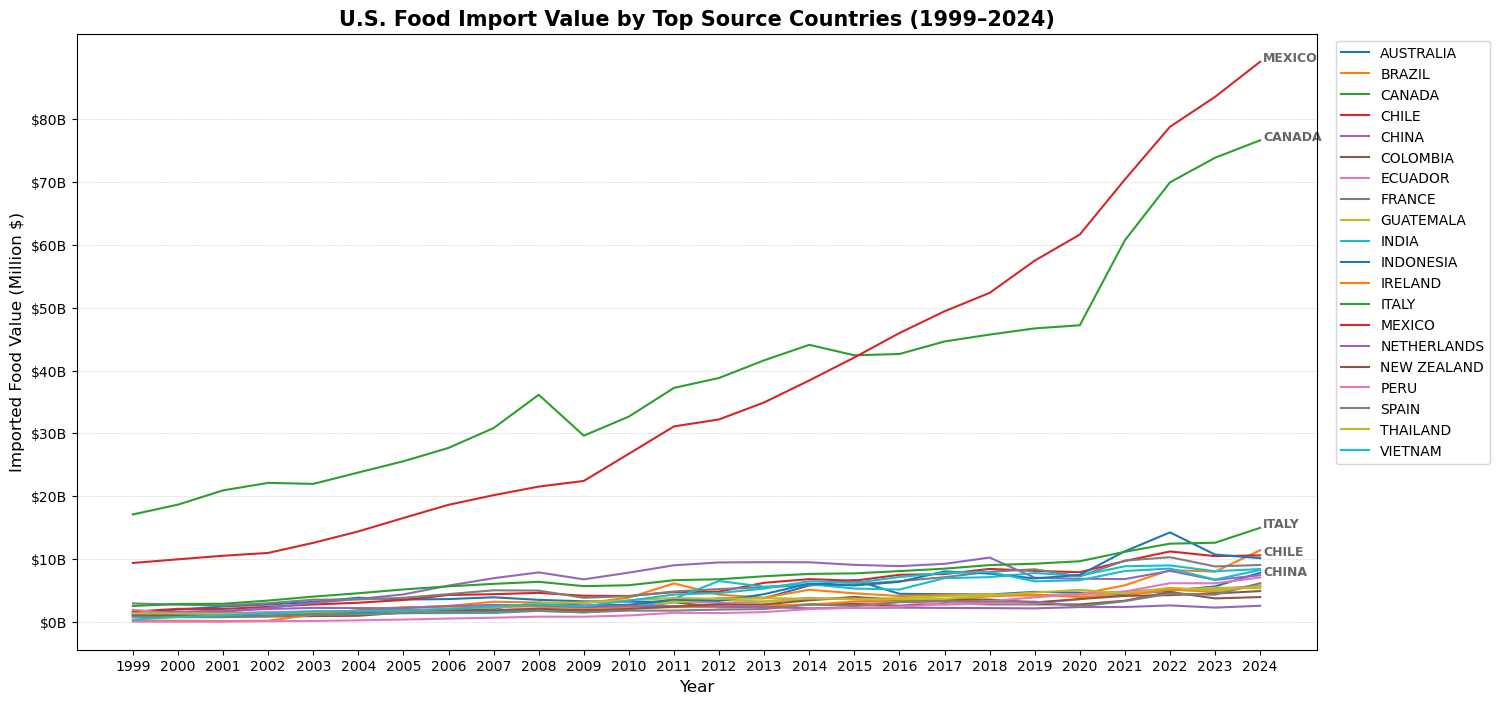

In [115]:
import pandas as pd 
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

df = pd.read_csv('FoodImports.csv', encoding="cp1252")
df = df.drop(columns=['RowNumber'])
df = df[df['UOM'] == 'Million $']
df['YearNum'] = df['YearNum'].astype(int)
exclude_country = ['WORLD', 'REST OF WORLD']
df = df[~df['Country'].isin(exclude_country)]

country_total = df.groupby('Country')['FoodValue'].sum().sort_values(ascending=False)
df_top20 = country_total.head(20).index.tolist()
df_top5 = country_total.head(5).index.tolist()
df = df[df['Country'].isin(df_top20)]

Food_value_change = df.groupby(['Country', 'YearNum'])['FoodValue'].sum().reset_index()
wide_df = Food_value_change.pivot(index='YearNum', columns='Country', values='FoodValue').sort_index()

ax = wide_df.plot(kind='line', figsize=(16, 8))

for country in df_top5:
    if country in wide_df:
        last_year = wide_df.index[-1]
        last_value = wide_df[country].iloc[-1]
        ax.annotate(country, 
                    xy=(last_year, last_value),
                    xytext=(2, 0),                       
                    textcoords='offset points',
                    fontsize=9,
                    fontweight='bold',
                    alpha=0.6)
        
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}B"))   

plt.xlabel('Year', fontsize=12)
plt.ylabel('Imported Food Value (Million $)', fontsize=12)
plt.title('U.S. Food Import Value by Top Source Countries (1999–2024)', fontsize=15, fontweight='bold')
plt.legend(bbox_to_anchor=(1.01, 1), loc='best')

y_min = Food_value_change['FoodValue'].min()
y_max = Food_value_change['FoodValue'].max()
ax.set_yticks(np.arange(y_min, y_max, 10000)) 
plt.grid(axis='y', linestyle='--', linewidth=0.5, alpha=0.5)
years = wide_df.index.tolist()
plt.xticks(years)
plt.savefig("D:/Data analysis/US-Food-Import-Analysis/U.S. Food Import Value by Countries (1999–2024).png", bbox_inches='tight')
plt.show()


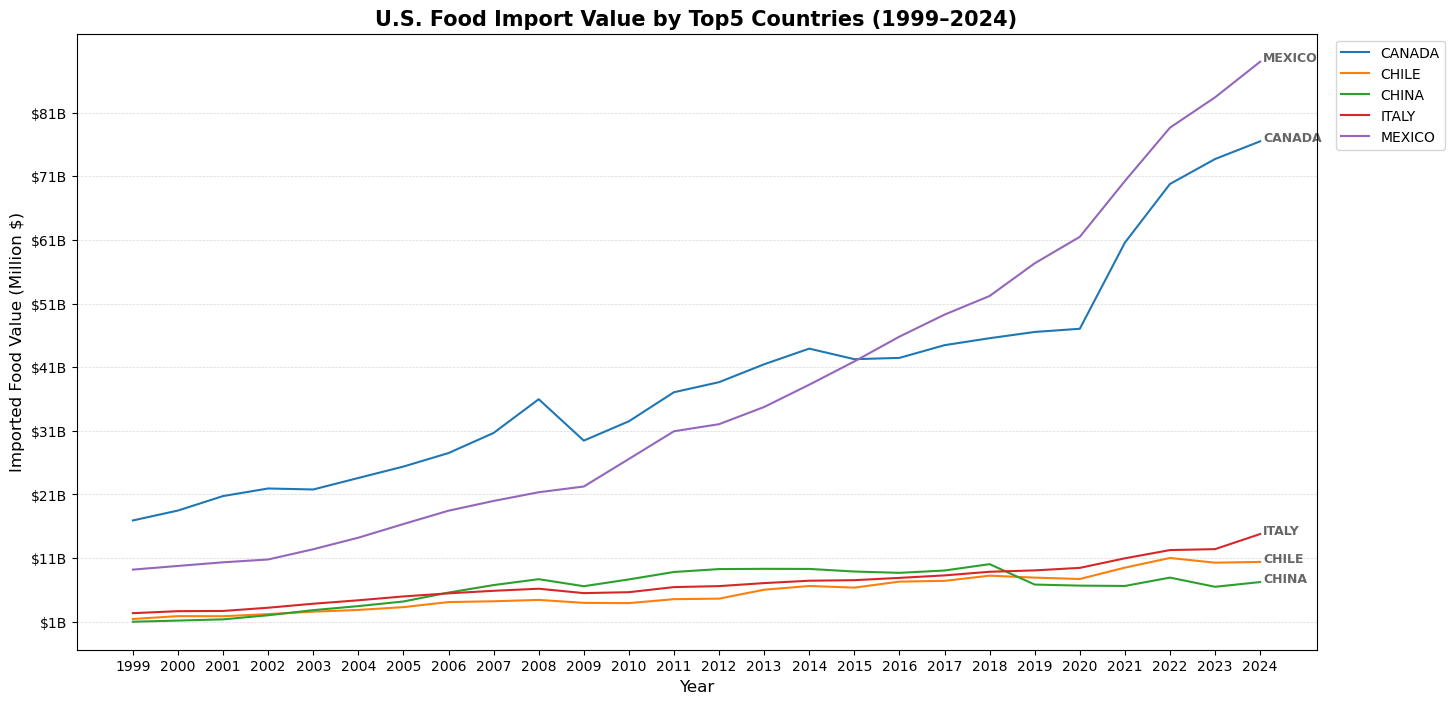

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

df = pd.read_csv('FoodImports.csv', encoding="cp1252")
df = df.drop(columns=['RowNumber'])
df = df[df['UOM'] == 'Million $']
df['YearNum'] = df['YearNum'].astype(int)
exclude_country = ['WORLD', 'REST OF WORLD']
df = df[~df['Country'].isin(exclude_country)]

country_total = df.groupby('Country')['FoodValue'].sum().sort_values(ascending=False)
df_top5 = country_total.head(5).index.tolist()
df = df[df['Country'].isin(df_top5)]

Food_value_change = df.groupby(['Country', 'YearNum'])['FoodValue'].sum().reset_index()
wide_df = Food_value_change.pivot(index='YearNum', columns='Country', values='FoodValue').sort_index()

ax = wide_df.plot(kind='line', figsize=(16, 8))

for country in df_top5:
    if country in wide_df:
        last_year = wide_df.index[-1]
        last_value = wide_df[country].iloc[-1]
        ax.annotate(country, 
                    xy=(last_year, last_value),
                    xytext=(2, 0),                        
                    textcoords='offset points',
                    fontsize=9,
                    fontweight='bold',
                    alpha=0.6)
        
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}B"))   

plt.xlabel('Year', fontsize=12)
plt.ylabel('Imported Food Value (Million $)', fontsize=12)
plt.title('U.S. Food Import Value by Top5 Countries (1999–2024)', fontsize=15, fontweight='bold')
plt.legend(bbox_to_anchor=(1.01, 1), loc='best')

y_min = Food_value_change['FoodValue'].min()
y_max = Food_value_change['FoodValue'].max()
ax.set_yticks(np.arange(y_min, y_max, 10000)) 
plt.grid(axis='y', linestyle='--', linewidth=0.5, alpha=0.5)
years = wide_df.index.tolist()
plt.xticks(years)
plt.savefig("D:/Data analysis/US-Food-Import-Analysis/U.S. Food Import Value by Top5 Countries (1999–2024).png", bbox_inches='tight')
plt.show()


In [46]:
import pandas as pd 
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

df = pd.read_csv('FoodImports.csv', encoding="cp1252")
df = df.drop(columns=['RowNumber'])
df = df[df['UOM'] == 'Million $']
df['YearNum'] = df['YearNum'].astype(int)
exclude_country = ['WORLD']
df = df[~df['Country'].isin(exclude_country)]

category_total = df.groupby('Category')['FoodValue'].sum().sort_values(ascending=False)
Food_value_change = df.groupby(['Category', 'YearNum'])['FoodValue'].sum().reset_index()
wide_df = Food_value_change.pivot(index='YearNum', columns='Category', values='FoodValue').sort_index()
wide_df

Category,Animals,Beverages,Cocoa,Coffee,Dairy,Fish,Fruits,Grains,Meats,Nuts,Other,Sweets,Vegetables,VegetablesOil
YearNum,,,,,,,,,,,,,,
1999,2358.7,11818.9,3044.4,7207.4,1860.6,17719.6,10762.3,5870.4,5757.8,2013.9,2117.4,3187.0,7259.2,3162.2
2000,2820.3,12936.0,2807.5,6883.6,1844.6,19759.7,10397.6,5982.0,6835.8,2057.5,2096.7,3121.8,7538.9,3248.5
2001,3522.7,13637.0,3070.9,4801.4,1991.6,19326.6,10504.1,6527.7,7662.0,1693.3,2249.0,3213.1,8308.8,2732.9
2002,3419.2,15363.4,3520.7,4910.0,2017.6,19926.7,11293.2,7227.3,7625.5,1762.7,2479.5,3720.9,8777.5,3118.7
2003,2530.9,17327.4,4877.4,5743.9,2220.6,21719.8,12241.1,7668.0,7712.8,1940.8,3633.6,4275.5,10160.5,3656.6
2004,2235.5,18425.8,4967.9,6288.7,2584.7,22212.6,13030.4,8586.0,10097.2,2709.4,4777.6,4228.8,11454.5,5369.5
2005,3322.4,20512.3,5500.6,7541.7,2776.9,23680.4,15004.5,9008.1,10094.9,2795.2,5529.7,5001.6,12078.9,5850.3
2006,4312.7,23540.8,5318.0,8389.8,2811.4,26224.5,16676.4,10596.9,9027.1,2709.4,5955.1,6111.1,13230.3,6958.0
2007,5132.6,25602.6,5323.1,9582.4,3001.7,26869.2,19739.6,12915.1,9176.1,2930.1,6067.4,5214.2,14502.3,8524.0


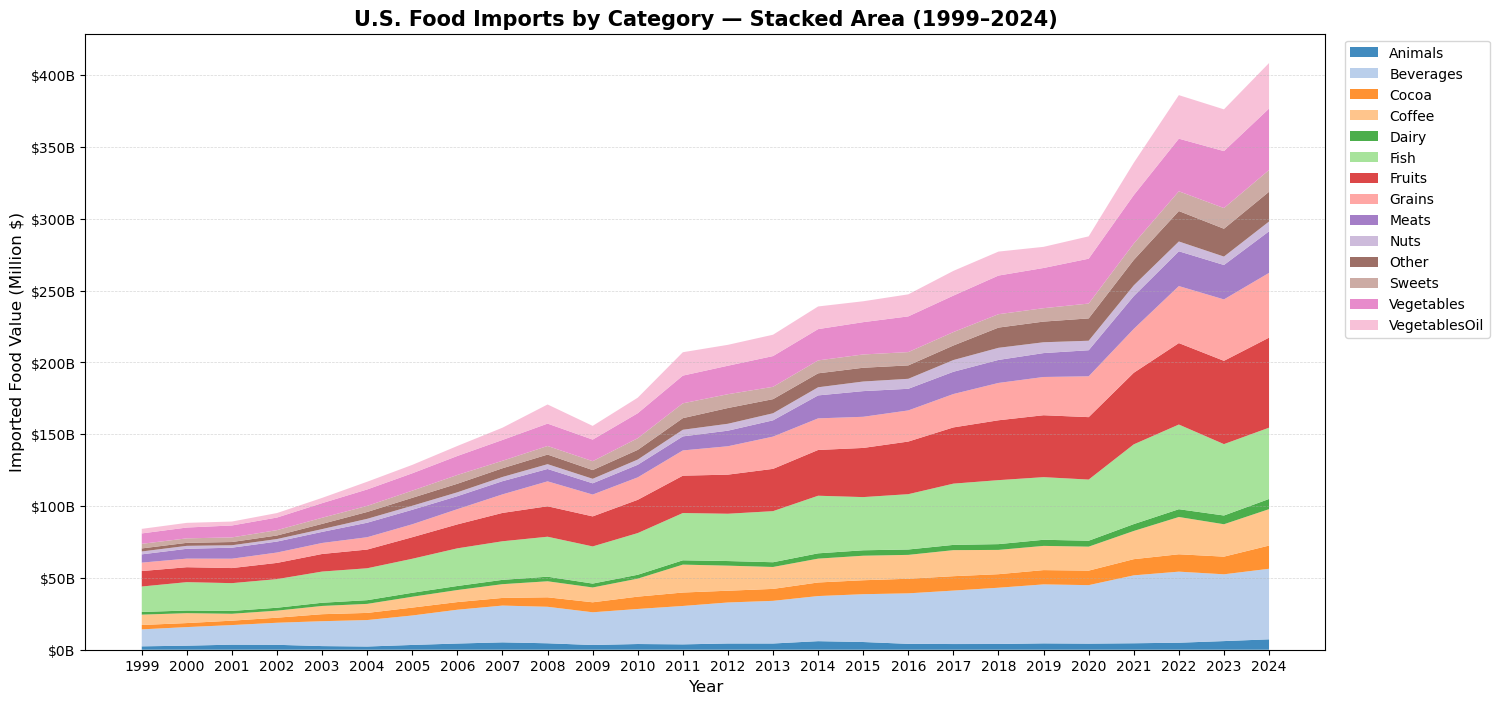

In [3]:
import pandas as pd 
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

df = pd.read_csv('FoodImports.csv', encoding="cp1252")
df = df.drop(columns=['RowNumber'])
df = df[df['UOM'] == 'Million $']
df['YearNum'] = df['YearNum'].astype(int)
exclude_country = ['WORLD']
df = df[~df['Country'].isin(exclude_country)]

category_total = df.groupby('Category')['FoodValue'].sum().sort_values(ascending=False)
Food_value_change = df.groupby(['Category', 'YearNum'])['FoodValue'].sum().reset_index()
wide_df = Food_value_change.pivot(index='YearNum', columns='Category', values='FoodValue').sort_index()

colors = plt.cm.tab20.colors[:len(wide_df.columns)]

fig, ax = plt.subplots(figsize=(16, 8))

ax.stackplot(wide_df.index, wide_df.T.values, labels=wide_df.columns, colors=colors, alpha=0.85)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}B"))   

plt.xlabel('Year', fontsize=12)
plt.ylabel('Imported Food Value (Million $)', fontsize=12)
plt.title('U.S. Food Imports by Category — Stacked Area (1999–2024)', fontsize=15, fontweight='bold')
plt.legend(bbox_to_anchor=(1.01, 1), loc='best')
plt.grid(axis='y', linestyle='--', linewidth=0.5, alpha=0.5)
years = wide_df.index.tolist()
plt.xticks(years)
plt.savefig("D:/Data analysis/US-Food-Import-Analysis/U.S. Food Imports by Category — Stacked Area (1999–2024).png", bbox_inches='tight')
plt.show()


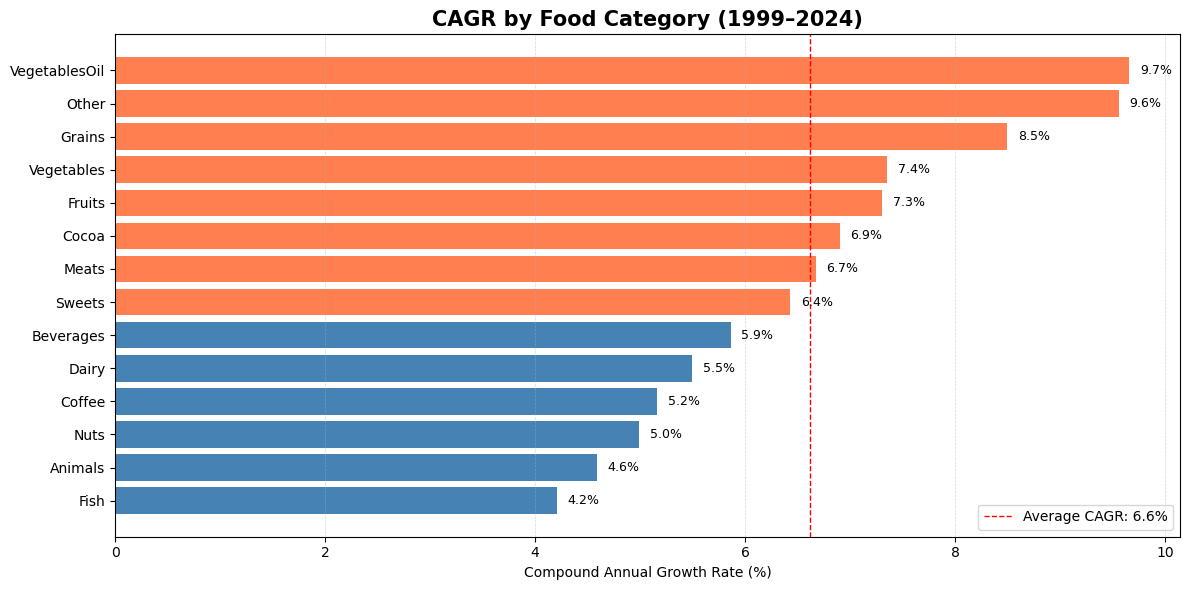

In [44]:
import pandas as pd 
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

df = pd.read_csv('FoodImports.csv', encoding="cp1252")
df = df.drop(columns=['RowNumber'])
df = df[df['UOM'] == 'Million $']
df['YearNum'] = df['YearNum'].astype(int)
exclude_country = ['WORLD']
df = df[~df['Country'].isin(exclude_country)]

cat_year = df.groupby(["Category", "YearNum"])["FoodValue"].sum().unstack()

def cagr(start, end, n):
    if start <= 0 or pd.isna(start) or pd.isna(end):
        return np.nan
    return (end / start) ** (1 / n) - 1

n_years = 2024 - 1999
cagr_vals = {}

for cat in cat_year.index:
    s = cat_year.loc[cat].get(1999, np.nan)
    e = cat_year.loc[cat].get(2024, np.nan)
    cagr_vals[cat] = cagr(s, e, n_years) * 100

cagr_s = pd.Series(cagr_vals).dropna().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(
    cagr_s.index,
    cagr_s.values,
    color=["red" if v < 3 else "coral" if v > 6 else "steelblue" for v in cagr_s.values]
)

avg = float(cagr_s.mean())
ax.axvline(avg, color="red", linestyle="--", linewidth=1.0, label=f"Average CAGR: {avg:.1f}%")

for bar, val in zip(bars, cagr_s.values):
    ax.text(val + 0.1, bar.get_y() + bar.get_height() / 2, f"{val:.1f}%", va="center", fontsize=9)

ax.set_title("CAGR by Food Category (1999–2024)", fontsize=15, fontweight="bold")
ax.set_xlabel("Compound Annual Growth Rate (%)")
ax.legend()
ax.grid(axis="x", linestyle="--",  linewidth=0.5, alpha=0.5)
plt.tight_layout()
plt.savefig("D:/Data analysis/US-Food-Import-Analysis/CAGR by Food Category (1999–2024).png", bbox_inches='tight')
plt.show()

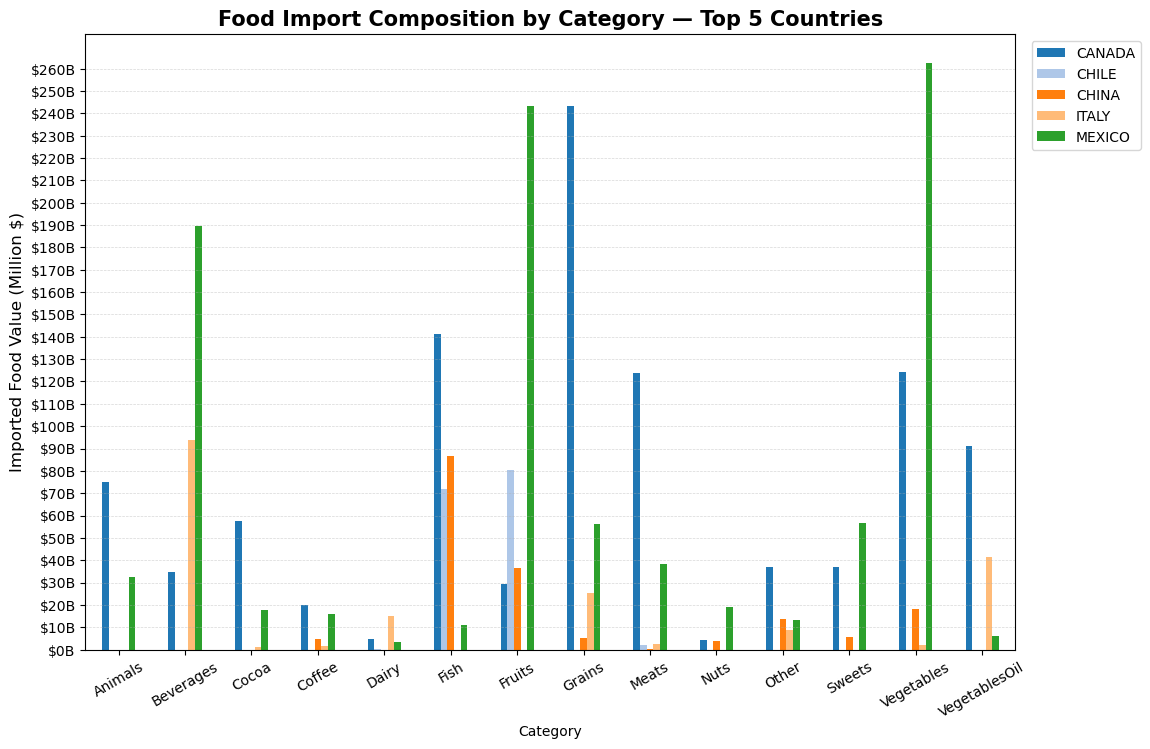

In [4]:
import pandas as pd 
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

df = pd.read_csv('FoodImports.csv', encoding="cp1252")
df = df.drop(columns=['RowNumber'])
df = df[df['UOM'] == 'Million $']
df['YearNum'] = df['YearNum'].astype(int)
exclude_country = ['WORLD', 'REST OF WORLD']
df = df[~df['Country'].isin(exclude_country)]

country_total = df.groupby('Country')['FoodValue'].sum().sort_values(ascending=False)
df_top5 = country_total.head(5).index.tolist()
df = df[df['Country'].isin(df_top5)]

Food_value_change = df.groupby(['Category', 'Country'])['FoodValue'].sum().reset_index()
wide_df = Food_value_change.pivot(index='Category', columns='Country', values='FoodValue').sort_index()

colors = plt.cm.tab20.colors[:len(wide_df.columns)]
ax = wide_df.plot(kind='bar', figsize=(12, 8), color=colors)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}B"))   

plt.ylabel('Imported Food Value (Million $)', fontsize=12)
plt.title('Food Import Composition by Category — Top 5 Countries', fontsize=15, fontweight='bold')
plt.legend(bbox_to_anchor=(1.01, 1), loc='best')

y_min = Food_value_change['FoodValue'].min()
y_max = Food_value_change['FoodValue'].max()
ax.set_yticks(np.arange(y_min, y_max, 10000)) 
plt.xticks(rotation=30)
plt.grid(axis='y', linestyle='--', linewidth=0.5, alpha=0.5)
plt.savefig("D:/Data analysis/US-Food-Import-Analysis/U.S.Food Import Composition by Category — Top 5 Countries.png", bbox_inches='tight')
plt.show()

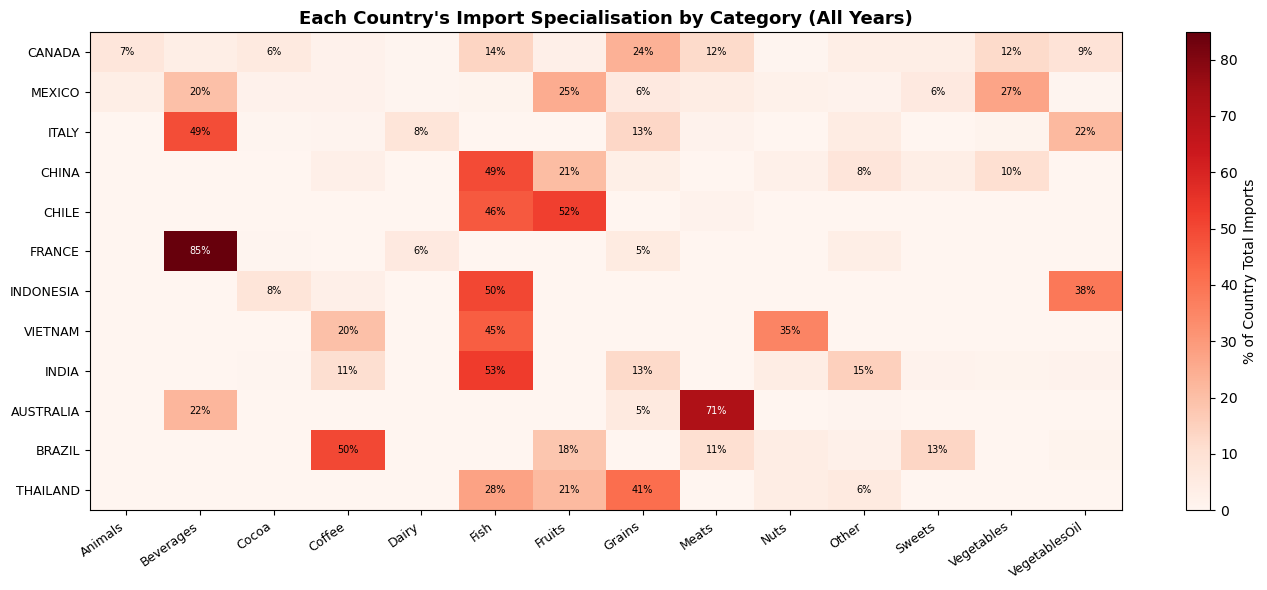

In [5]:
import pandas as pd 
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

df = pd.read_csv('FoodImports.csv', encoding="cp1252")
df = df.drop(columns=['RowNumber'])
df = df[df['UOM'] == 'Million $']
df['YearNum'] = df['YearNum'].astype(int)
exclude_country = ['WORLD', 'REST OF WORLD']
df = df[~df['Country'].isin(exclude_country)]

pivot_heat = (df.groupby(["Country", "Category"])["FoodValue"]
      .sum()
      .unstack(fill_value=0))

top12 = (
    df.groupby("Country")["FoodValue"]
      .sum()
      .sort_values(ascending=False)
      .head(12)
      .index
)

pivot_heat = pivot_heat.loc[top12]
pivot_heat_pct = pivot_heat.div(pivot_heat.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(14, 6))
im = ax.imshow(pivot_heat_pct.values, aspect="auto", cmap="Reds")

ax.set_xticks(range(len(pivot_heat_pct.columns)))
ax.set_xticklabels(pivot_heat_pct.columns, rotation=35, ha="right", fontsize=9)
ax.set_yticks(range(len(pivot_heat_pct.index)))
ax.set_yticklabels(pivot_heat_pct.index, fontsize=9)

plt.colorbar(im, ax=ax, label="% of Country Total Imports")

ax.set_title("Each Country's Import Specialisation by Category (All Years)", fontsize=13, fontweight="bold")

for i in range(len(pivot_heat_pct.index)):
    for j in range(len(pivot_heat_pct.columns)):
        val = pivot_heat_pct.values[i, j]
        if val > 5:
            ax.text(j, i, f"{val:.0f}%", ha="center", va="center",
                    fontsize=7, color="black" if val < 60 else "white")

plt.tight_layout()
plt.savefig("D:/Data analysis/US-Food-Import-Analysis/Each Country's Import Specialisation by Category (All Years).png", bbox_inches='tight')
plt.show()

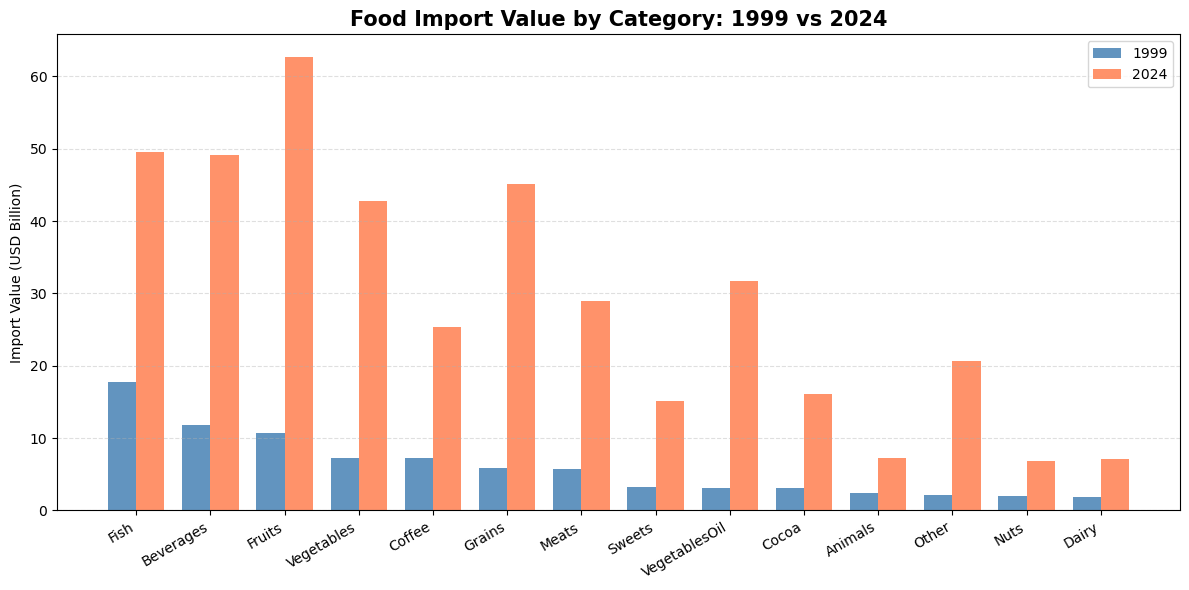

In [7]:
import pandas as pd 
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

df = pd.read_csv('FoodImports.csv', encoding="cp1252")
df = df.drop(columns=['RowNumber'])
df = df[df['UOM'] == 'Million $']
df['YearNum'] = df['YearNum'].astype(int)
exclude_country = ['WORLD']
df = df[~df['Country'].isin(exclude_country)]

cat_year = df.groupby(["Category", "YearNum"])["FoodValue"].sum().unstack()

val_1999 = cat_year[1999].sort_values(ascending=False)
val_2024 = cat_year[2024].reindex(val_1999.index)

x = np.arange(len(val_1999))
width = 0.38

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - width/2, val_1999.values / 1000, width, label="1999", color="steelblue", alpha=0.85)
ax.bar(x + width/2, val_2024.values / 1000, width, label="2024", color="coral", alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(val_1999.index, rotation=30, ha="right")
ax.set_ylabel("Import Value (USD Billion)")
ax.set_title("Food Import Value by Category: 1999 vs 2024", fontsize=15, fontweight="bold")
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("D:/Data analysis/US-Food-Import-Analysis/Food Import Value by Category: 1999 vs 2024.png", bbox_inches='tight')
plt.show()
